# Lasso Regression (L1)

**Flow:** sparse signal → coefficient paths (signal vs noise) → alpha by CV on training data → held-out evaluation.

Lasso adds an L1 penalty and can drive coefficients to **exactly zero**. A zero coefficient is not proof that a feature is intrinsically unimportant, especially among correlated predictors.

## 1. Setup and versions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(42)

OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]


In [2]:
# Environment / version info for reproducibility
import sys
import numpy as np
import scipy
import sklearn
import matplotlib

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


## 2. Data with 3 signal features and 9 noise features
Only the first three coefficients are non-zero in the ground truth. We split before fitting.

In [3]:
n_features = 12
X = rng.normal(size=(200, n_features))
truth = np.r_[3.0, -2.0, 1.5, np.zeros(n_features - 3)]
y = X @ truth + rng.normal(0, 0.8, size=200)
signal_idx = np.array([0, 1, 2])
noise_idx = np.arange(3, n_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)
print(f'Train/test sizes: {X_train.shape[0]} / {X_test.shape[0]}')
print(f'True non-zero features: {signal_idx.tolist()}')


Train/test sizes: 140 / 60
True non-zero features: [0, 1, 2]


## 3. Coefficient paths: signal vs noise
Signal features are drawn as solid colored lines; noise features as thin gray dashed lines. This separates the two groups without relying on color perception alone.

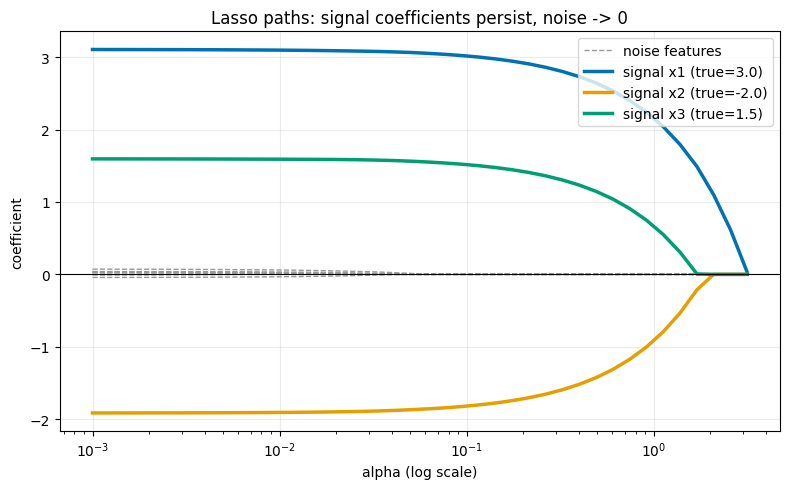

In [4]:
alphas = np.logspace(-3, 0.5, 40)
paths = []
for a in alphas:
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('lasso', Lasso(alpha=a, max_iter=10000)),
    ]).fit(X_train, y_train)
    paths.append(pipe.named_steps['lasso'].coef_)
paths = np.array(paths)

plt.figure(figsize=(8, 5))
for j in noise_idx:
    plt.semilogx(alphas, paths[:, j], color='0.6', ls='--', lw=1,
                 label='noise features' if j == noise_idx[0] else None)
for k, j in enumerate(signal_idx):
    plt.semilogx(alphas, paths[:, j], color=OKABE_ITO[k], lw=2.5,
                 label=f'signal x{j + 1} (true={truth[j]:.1f})')
plt.axhline(0, color='black', lw=0.8)
plt.title('Lasso paths: signal coefficients persist, noise -> 0')
plt.xlabel('alpha (log scale)'); plt.ylabel('coefficient')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 4. Sparsity vs alpha
The number of non-zero coefficients falls as alpha increases. This is the feature-selection behavior of L1.

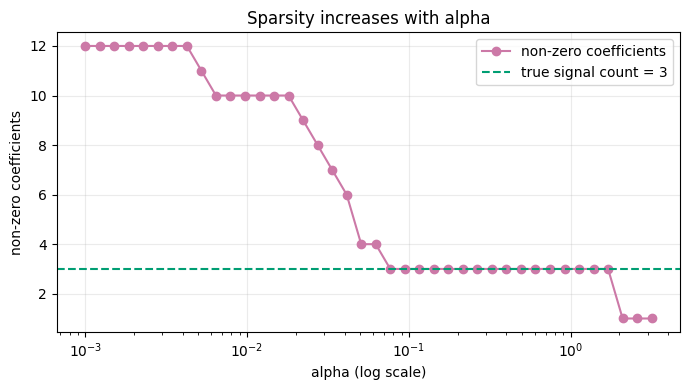

In [5]:
n_nonzero = (np.abs(paths) > 1e-8).sum(axis=1)
plt.figure(figsize=(7, 4))
plt.semilogx(alphas, n_nonzero, color=OKABE_ITO[4], marker='o',
             label='non-zero coefficients')
plt.axhline(len(signal_idx), color=OKABE_ITO[2], ls='--',
            label='true signal count = 3')
plt.title('Sparsity increases with alpha')
plt.xlabel('alpha (log scale)'); plt.ylabel('non-zero coefficients')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 5. Select alpha by CV on training data, evaluate on test
`LassoCV` cross-validates the alpha grid on the training data. We report which features survived and the final held-out metrics.

Best alpha (CV): 0.09427
Kept features  : ['x1', 'x2', 'x3']
Test R2        : 0.942
Test MSE       : 0.881


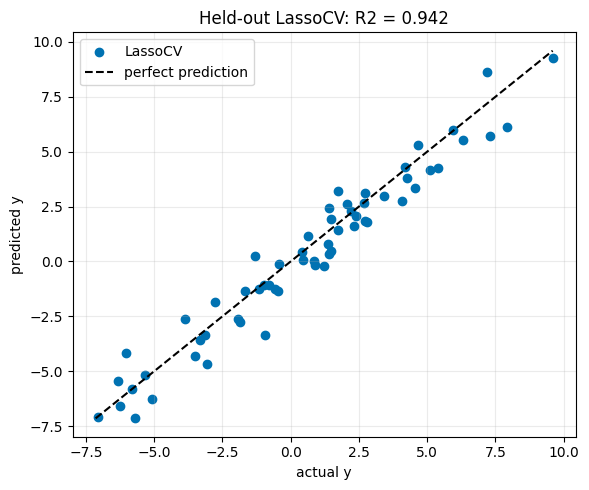

In [6]:
lasso_cv = Pipeline([
    ('scale', StandardScaler()),
    ('lasso', LassoCV(alphas=alphas, cv=5, max_iter=20000,
                      random_state=0)),
]).fit(X_train, y_train)

best_alpha = lasso_cv.named_steps['lasso'].alpha_
coef = lasso_cv.named_steps['lasso'].coef_
kept = np.where(np.abs(coef) > 1e-8)[0]
test_pred = lasso_cv.predict(X_test)

print(f'Best alpha (CV): {best_alpha:.4g}')
print(f'Kept features  : {[f"x{i + 1}" for i in kept]}')
print(f'Test R2        : {r2_score(y_test, test_pred):.3f}')
print(f'Test MSE       : {mean_squared_error(y_test, test_pred):.3f}')

lim = [min(y_test.min(), test_pred.min()),
       max(y_test.max(), test_pred.max())]
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred, color=OKABE_ITO[0], label='LassoCV')
plt.plot(lim, lim, color='black', ls='--', label='perfect prediction')
plt.title(f'Held-out LassoCV: R2 = {r2_score(y_test, test_pred):.3f}')
plt.xlabel('actual y'); plt.ylabel('predicted y')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## Takeaways
- Lasso yields sparse solutions; noise coefficients go to zero.
- Among correlated features it may keep one and drop another, so treat selection as evidence, not proof.
- Choose alpha with LassoCV on training data; report test metrics once.